***PROMO TARGETING - Exploratory Data Analysis***

***I. Introduction & Business Context***

This exploratory data analysis supports a customer prioritization model designed to predict which customers should be targeted for promotions to maximize near-term (60-day) revenue. The dataset used is the UCI Online Retail transaction dataset. Transactions were split using a cutoff date of October 10, 2011, with customer behavioral features calculated before the cutoff and the target variable defined as revenue in the 60 days after the cutoff. 

My assumptions are that high Monetary, high Frequency and low recency will predict good near-term revenue.  If a customer spends a lot of money, they will most likely contribute greatly to near-term value.  If a customer buys products frequently, they will continue to purchase frequently in the near term.  If a customer purchases something recently (low recency), they are more likely to purchase again soon.


The purpose of this EDA is to understand feature distributions, relationships with the target, and data quality issues before regression modeling.


In [1]:
### Loading Libraries

import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import scale

In [2]:
### Load EDA DataFrame

df = pd.read_csv('/Users/elliotgaynon/Desktop/CAP3/Capstone3/data/processed/capstone3_customer_modeling_table_For_EDA.csv')

In [3]:
df.describe()

,CustomerID,recency,frequency,monetary,avg_order_value,target_60day_revenue
count,3731.000000,3731.000000,3731.000000,3731.000000,3731.000000,3731.000000
mean,15276.365854,92.700884,3.676494,1748.219787,408.856860,550.139268
std,1720.658779,88.850967,6.271227,7296.654491,1357.896516,3615.879271
min,12346.000000,0.000000,1.000000,2.900000,2.900000,0.000000
25%,13779.000000,18.000000,1.000000,289.355000,177.397500,0.000000
50%,15254.000000,60.000000,2.000000,602.840000,296.640000,0.000000
75%,16754.500000,150.500000,4.000000,1457.835000,434.937222,455.100000
max,18287.000000,313.000000,145.000000,203948.190000,77183.600000,168469.600000


***II. Data Overview***

In [4]:
### Show the Dataset is model-ready and at the customer-level

df.shape

(3731, 6)

In [5]:
df.dtypes

CustomerID                int64
recency                   int64
frequency                 int64
monetary                float64
avg_order_value         float64
target_60day_revenue    float64
dtype: object

In [6]:
df.head()

,CustomerID,recency,frequency,monetary,avg_order_value,target_60day_revenue
0,12346,265,1,77183.60,77183.600000,0.00
1,12347,69,5,2790.86,558.172000,1519.14
2,12348,14,4,1797.24,449.310000,0.00
3,12350,249,1,334.40,334.400000,0.00
4,12352,11,7,2194.31,313.472857,311.73


From the data, one can see we have 3,731 rows and 6 columns. Each row represents one customer.  Our columns define our Features and our Target for modeling.  Our Features are 'recency', 'frequency', 'monetary', and 'avg_order_value'.  Our Target is 'target_60day_revenue'.

***III. Univariate Analysis***

***IIIa. Target Variable***

The target variable is 'target_60day_revenue'.  In order to understand it's distribution, I will create a histogram.

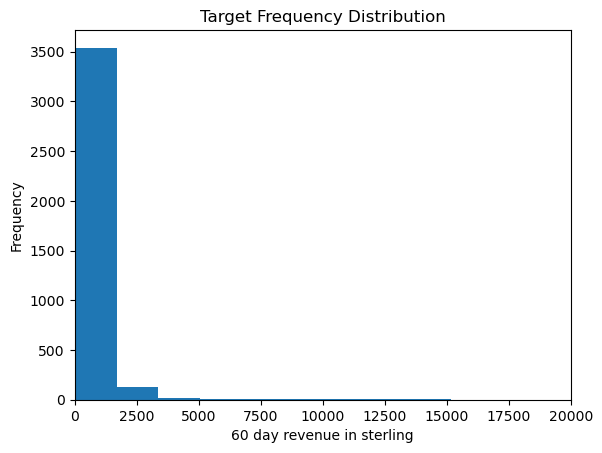

In [7]:
### Target Distribution

fig, ax = plt.subplots()
ax.hist(df['target_60day_revenue'], bins=100)
plt.xlim(0,20000)
ax.set_xlabel('60 day revenue in sterling')
ax.set_ylabel('Frequency')
ax.set_title('Target Frequency Distribution')
plt.show()

This appears to be a right-skew with a long tail.  We can infer that many customers are clustered at very low values close to or at zero. Most customers buy very little.  As the tail stretches rightwards, we start to see a small number of customers who have large revenue values. These rare few are high-value buyers.  One question that arises is how many customers's 60 day revenue was 0?

In [8]:
### % of Target revenue = 0?

(df['target_60day_revenue'] == 0).mean()

np.float64(0.5205038863575449)

Approximately 52% of customers generated zero revenue in the 60-day post-cutoff window. Over half of all customers bought nothing. This confirms that the target variable is zero-inflated and highly skewed, which is typical in customer purchase behavior. It also reinforces the business value of predictive targeting, since a majority of customers do not purchase in the near term. What a waste of time it would be to market to those people.

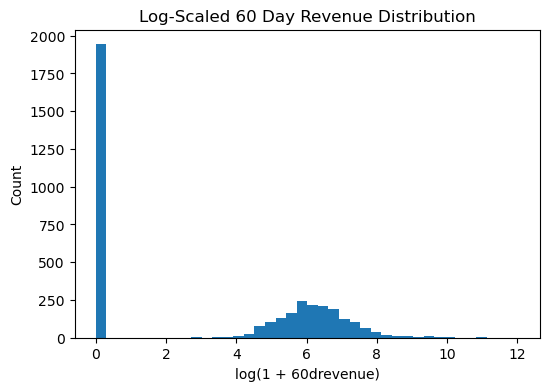

In [31]:
### Log Transform the target variable

plt.figure(figsize=(6,4))
plt.hist(np.log1p(df['target_60day_revenue']), bins=40)
plt.title("Log-Scaled 60 Day Revenue Distribution")
plt.xlabel("log(1 + 60drevenue)")
plt.ylabel("Count")
plt.show()

***IIIb. Feature Distributions***

array([[<Axes: title={'center': 'recency'}>,
        <Axes: title={'center': 'frequency'}>],
       [<Axes: title={'center': 'monetary'}>,
        <Axes: title={'center': 'avg_order_value'}>]], dtype=object)

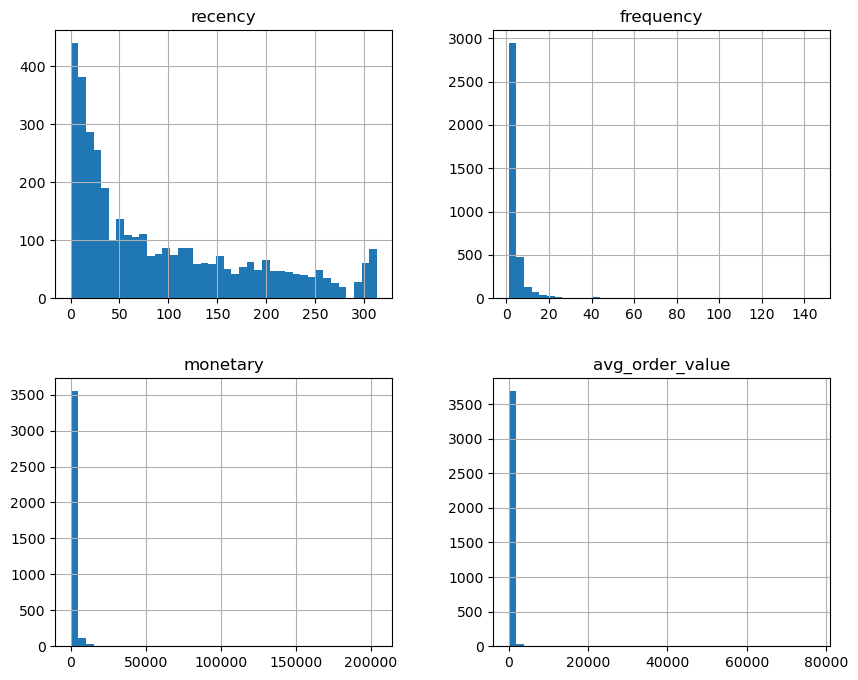

In [9]:
cols = ['recency','frequency','monetary','avg_order_value']
df[cols].hist(bins=40, figsize=(10,8))

***IIIb. 1 - Recency***

Recency measures the days since last purchase before cut-off.  A lower recency indicates more recent purchases, and thus a more engaged consumer. The recency graph above appears right-skewed. One can see many customers with low recency.  These are customers that are actively engaged.  However, there seems to be a not quite insignificant chunk of high recency.  These are customers who may be inactive or at risk of becoming inactive.  Generally, promotions work better on customers with more recent activities. We must target them.

***IIIb. 2 - Frequency***

Frequency is the number of unique invoices per customer pre-cutoff date.  From the graph, when one sees a big spike in the beginning and a rapid drop-off, one is seeing a right-skew.  In other words, there are very few high-frequency customers, as most customers make 1 or 2 purchases. Thus, repeat purchasing behavior has an uneven distribution and may be predictive of near-term revenue.

***IIIb. 3 - Monetary Value***

Monetary value is how much each customer spent in total, pre-cutoff date.  From the above graph one sees a strong right-skew with a long tail.  There are very few large spenders. However, these high monetary customers possess high value and high promotion upside.  They may also be bulk buyers. That said, the concentration of value among a few customers is typical in retail data and supports the need for value-based targeting.

***IIIb. 4 - Average Order Value***

AOV measures how much each customer spent per order.  In this graph we see another heavy right-skew with long tail.  This indicates that while most customers place modest size orders, a small group regularly places large orders.This feature serves as a useful proxy for promotional revenue potential because it compares frequent small buyers vs. infrequent big buyers.

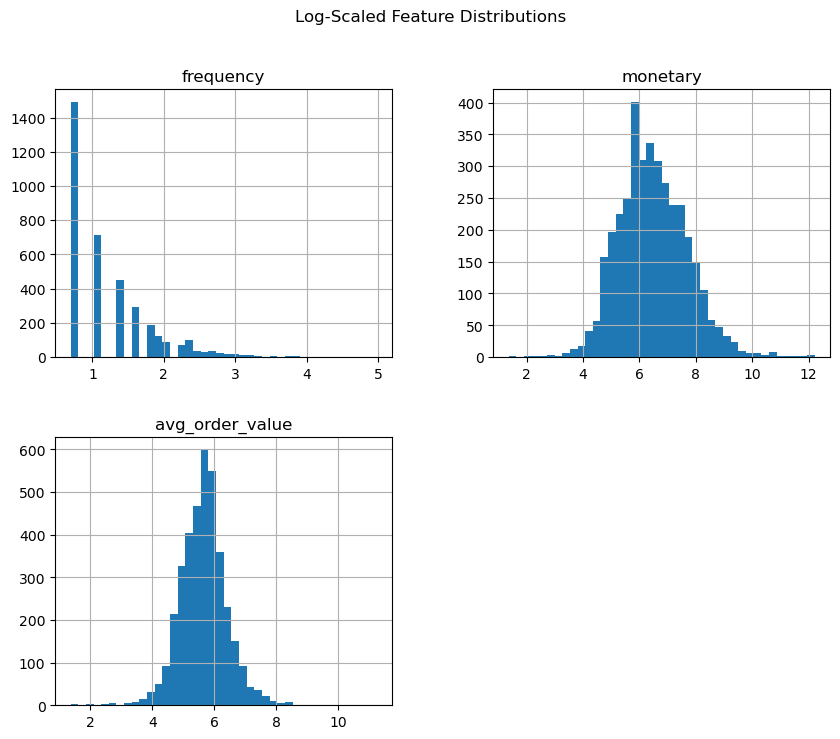

In [33]:
### Log Transform features

cols = ['frequency','monetary','avg_order_value']

df_log = df[cols].apply(np.log1p)

df_log.hist(bins=40, figsize=(10,8))
plt.suptitle("Log-Scaled Feature Distributions")
plt.show()

After log-scaling, distributions look smoother.  Monetary and avg_order_value appear to be normal distrubtions.  Frequency Remains right-skew but it's tail is visible and it's spread is easier to see.

***Boxplots for outliers***

Because Frequency, Montary Value, and AOV are highly right-skewed I want create boxplots in order to confirm the existence of outliers in these spending related features.

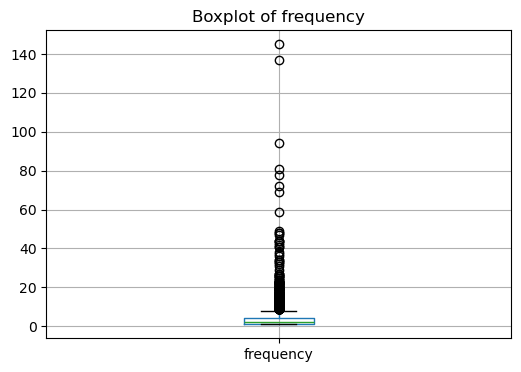

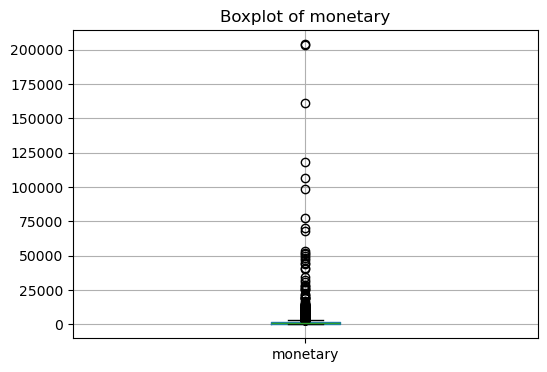

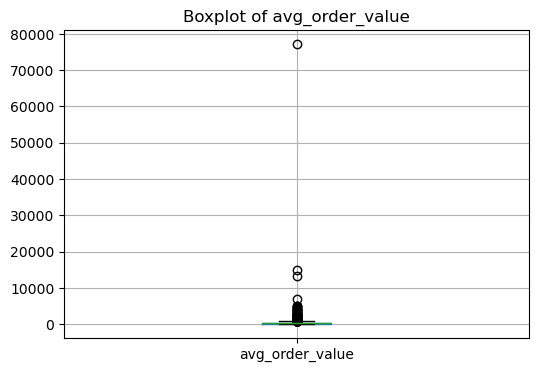

In [10]:
### Individual Boxplots

for col in ['frequency','monetary','avg_order_value']:
    plt.figure(figsize=(6,4))
    df.boxplot(column=col)
    plt.title(f'Boxplot of {col}')
    plt.show()

Due to the right-skew of features, it's hard to discern anything from the graph.  Like the histograms, I applied log transformations for better visualization.

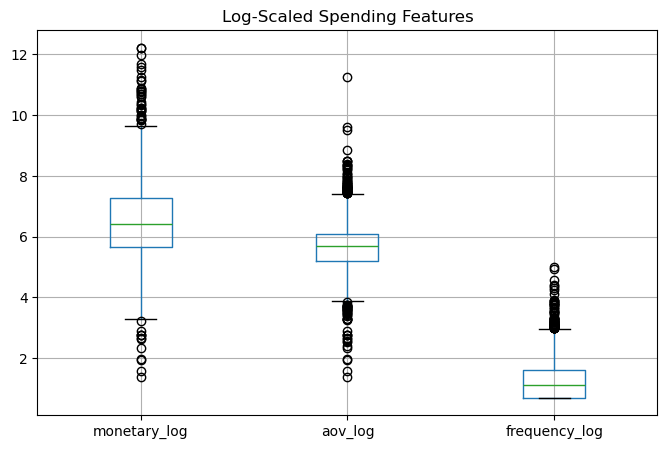

In [11]:
### Log Scale plots for monetary/AOV

df['monetary_log'] = np.log1p(df['monetary'])
df['aov_log'] = np.log1p(df['avg_order_value'])
df['frequency_log'] = np.log1p(df['frequency'])
plt.figure(figsize=(8,5))
df[['monetary_log','aov_log','frequency_log']].boxplot()
plt.title("Log-Scaled Spending Features")
plt.show()

After log transformation, frequency, monetary, and AOV features show many values beyond the boxplot outlier threshold.  This reflects the natural long-tail structure of customer purchase behavior rather than data error. These values appear plausible for wholesale transactions and will be retained, through transformations may be considered during modeling.

Consider transformations for 'monetary', 'frequency', and 'aov'.

***IV. Bivariate Analysis: Feature vs Target Relationships - Scatterplots***

The target is 'target_60day_revenue' and the features are 'recency', 'frequency' , 'monetary', and 'avg_order_value'.  I am looking to see if higher RFM + proxy metrics relate to higher 60-day revenue. Because the data is skewed, I will use a log scale on target for visibility.

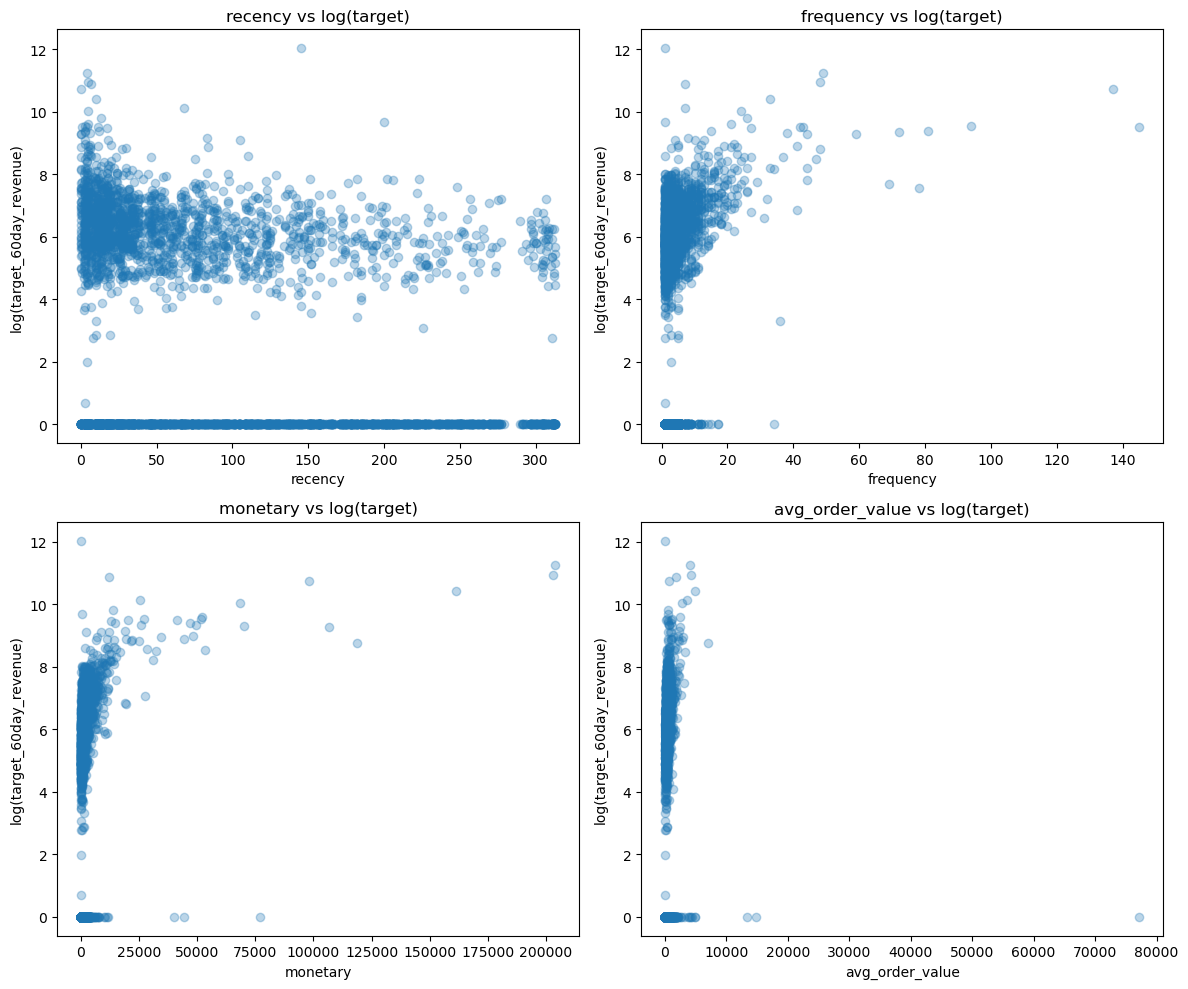

In [12]:
### Scatterplot - Features vs Target

features = ['recency','frequency','monetary','avg_order_value']

fig, axes = plt.subplots(2, 2, figsize=(12,10))

for ax, col in zip(axes.flatten(), features):
    ax.scatter(df[col], np.log1p(df['target_60day_revenue']), alpha=0.3)
    ax.set_title(f"{col} vs log(target)")
    ax.set_xlabel(col)
    ax.set_ylabel("log(target_60day_revenue)")

plt.tight_layout()
plt.show()

***Recency vs Target***

The appearance of the flat cloud indicates no visible linear relationship between recency and the target variable.  

***Frequency vs Target***

A thick cluster of customers appears to almost "hug" the y-axis.  This means that most customers have very few purchases. And a very small amount of cusotmers have high counts of purchases.  However, there is a slight positive trend, which is a good thing.

***Monetary vs Target***

This also hugs the y-axis.  As we've seen in previous graphs, spending is extremely skewed.  Most customers spend very little-to-moderate amounts. High spenders are rare.  There also appears to be a weakly positive slope.

***AOV vs Target***

AOV shows a very weak scatter signal.  Perhaps this is due to being a secondary proxy feature.

***Scatterplot Conclusion:***
From the above scatterplots, one can see how the features have weak-to-moderate visibile relationship with the 60-day revenue target.  Frequency and Monetary show somewhat positive trends, while recency appears non-linear.  Due to heavy skew and zero-inflation in the target variable, additional analyses will be used to better assess feature relationships.

***IV. Bivariate Analysis: Feature vs Target Relationships - Bucketed Boxplots***

For the next section, I will bucket my target variable into groups and compare feature distributions.  In other words I'm trying to observe if higher target buckets show higher monetary or frequency ?  Also, do higher target buckets show lower recency? These relationships could show a strong promotional signal.

In [13]:
### - Manual creation of buckets zero spenders (52%), low spenders, medium spenders, and high spenders.

df['target_bucket'] = pd.cut(
    df['target_60day_revenue'],
    bins=[-1, 0, 200, 1000, df['target_60day_revenue'].max()],
    labels=['Zero','Low','Medium','High']
)


In [14]:
### - inspection of counts

df['target_bucket'].value_counts()

target_bucket
Zero      1942
Medium    1071
High       403
Low        315
Name: count, dtype: int64

Though the buckets aren't equal in size, they are still meaningful.

***Target vs Monetary Boxplot***

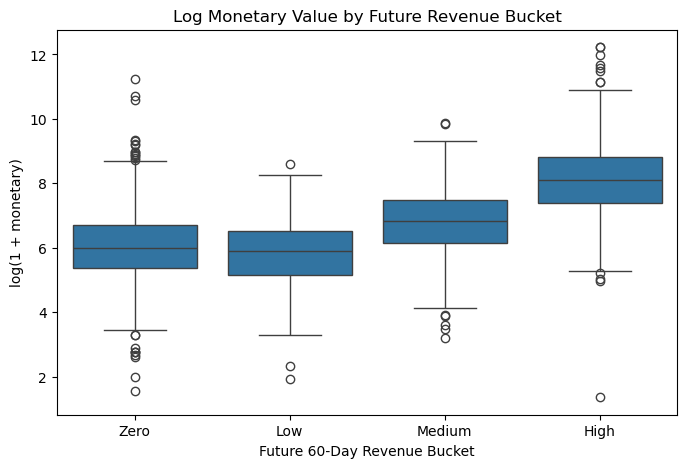

In [15]:
### Monetary vs Target Bucket Boxplot - note: log scale for monetary since it's skewed.

plt.figure(figsize=(8,5))

order = ['Zero','Low','Medium','High']

sns.boxplot(
    x='target_bucket',
    y=np.log1p(df['monetary']),
    data=df,
    order=order
)

plt.title("Log Monetary Value by Future Revenue Bucket")
plt.ylabel("log(1 + monetary)")
plt.xlabel("Future 60-Day Revenue Bucket")

plt.show()

As one can see, for the most part, monetary value increases across higher-future revenue buckets.  However, the data shows the "Zero" revenue in the future group to be slighty bigger spenders in the past than the "Low"  revenue in the future group.  This suggests that while prior spending is predictive, not all historically strong customers repurchase within the 60-day window.

In [16]:
### - Sanity Check

df.groupby('target_bucket')['monetary'].median()

/var/folders/8_/gv8z_wls7k381qn165ygj3jh0000gn/T/ipykernel_37482/1538400192.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('target_bucket')['monetary'].median()


target_bucket
Zero       402.575
Low        365.700
Medium     926.490
High      3298.860
Name: monetary, dtype: float64

Confirms high>>Medium>>Zero>>Low

***Target vs Frequency Boxplot***

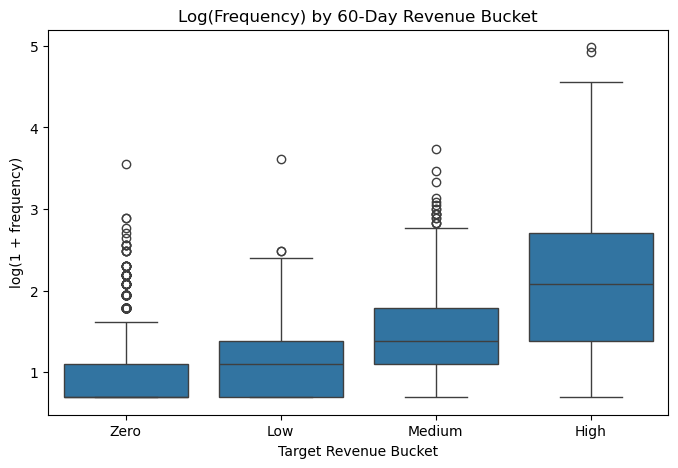

In [17]:
### Frequency vs Target Bucket Boxplot - note: another log scale for frequency since it's also skewed.

order = ['Zero','Low','Medium','High']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target_bucket',
    y=np.log1p(df['frequency']),
    data=df,
    order=order
)

plt.title("Log(Frequency) by 60-Day Revenue Bucket")
plt.ylabel("log(1 + frequency)")
plt.xlabel("Target Revenue Bucket")

plt.show()

The Median ordering is as follows Zero<Low<Medium<High.  This means that customers who bought more often before the cutoff window are likely to spend more in the next 60 days.

In [18]:
### Sanity check

df.groupby('target_bucket')['frequency'].median()

/var/folders/8_/gv8z_wls7k381qn165ygj3jh0000gn/T/ipykernel_37482/3699055119.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('target_bucket')['frequency'].median()


target_bucket
Zero      1.0
Low       2.0
Medium    3.0
High      7.0
Name: frequency, dtype: float64

This is a strong promotion targeting signal.

***Target vs Recency Boxplot***

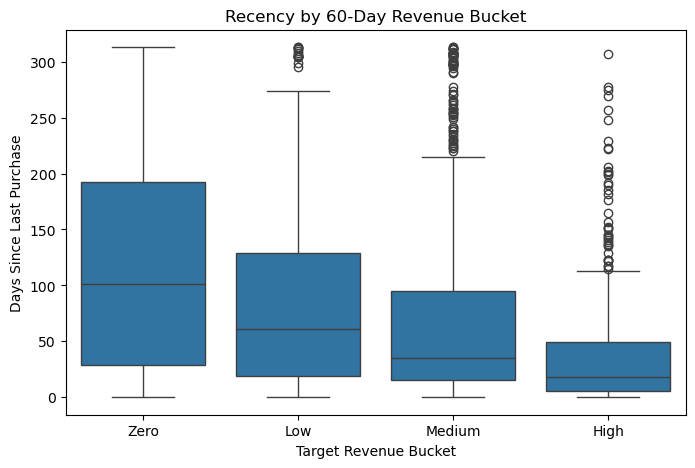

In [19]:
### Recency vs Target Bucket Boxplot - recency is in days.  Unlike frequency and monetary, smaller values are better.  Thus, we will keep it linear.

order = ['Zero','Low','Medium','High']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target_bucket',
    y='recency',
    data=df,
    order=order
)

plt.title("Recency by 60-Day Revenue Bucket")
plt.ylabel("Days Since Last Purchase")
plt.xlabel("Target Revenue Bucket")

plt.show()


From the graph, one can see the medians appear to descend from Zero to High. In other words, customers in the high target revenue bucket have the lowest median days since last purchase, while the customers with zero revenue have the highest median. In other words, customers who bought more recently before the cutoff will likely buy again soon.

In [20]:
### - Sanity Check

df.groupby('target_bucket')['recency'].median()

/var/folders/8_/gv8z_wls7k381qn165ygj3jh0000gn/T/ipykernel_37482/197459176.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('target_bucket')['recency'].median()


target_bucket
Zero      101.0
Low        61.0
Medium     35.0
High       18.0
Name: recency, dtype: float64

This confirms recency as a strong signal for promo priotization.

***Target vs AOV Boxplot***

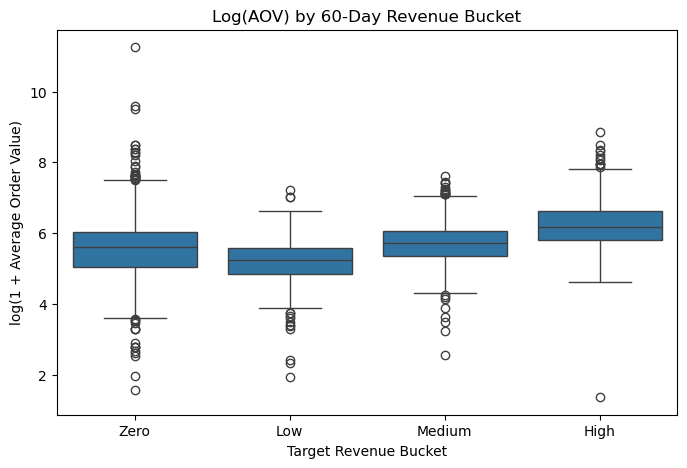

In [21]:
### Since AOV is heavily skewed, we'll use log scale for visualization

order = ['Zero','Low','Medium','High']

plt.figure(figsize=(8,5))

sns.boxplot(
    x='target_bucket',
    y=np.log1p(df['avg_order_value']),
    data=df,
    order=order
)

plt.title("Log(AOV) by 60-Day Revenue Bucket")
plt.ylabel("log(1 + Average Order Value)")
plt.xlabel("Target Revenue Bucket")

plt.show()

In [22]:
### Numerical values

df.groupby('target_bucket')['avg_order_value'].median()

/var/folders/8_/gv8z_wls7k381qn165ygj3jh0000gn/T/ipykernel_37482/385069561.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('target_bucket')['avg_order_value'].median()


target_bucket
Zero      272.78
Low       187.95
Medium    306.64
High      480.93
Name: avg_order_value, dtype: float64

Similar to the monetary plot, the median historical aov order ascends over target revenue low<zero<medium<high.  This means some customers in the zero bucket (those who made no purchases in the 60 day window) still had historically high AOV. That said, medium and high buckets show the expected increase in median.  This leads me to conclude that AOV is a weak signal, but still useful as a proxy if combined with other meaningful features such as frequency and recency.  Alone, however, it may mislead.

***Bucketing Conclusion:*** From the data one can see that Frequency and Recency are strong prioritization signals.  Monetary and AOV are moderate/supporting signals.  The observed "zero bucket" anomalies are valid customer behavior.

***V. Correlation Analysis***

After observing trends visually, I want to quantify relationships.  A Pearson Correlation heatmap will give numbers, which show the features most strongly associated with future revenue and which features are highly correlated with each other.

***V.a Building the Correlation Matrix***


I will build my correlation matrix around  all the features AND target variable.  I will exclude CustomerID and the bucket variables created in the last section.

In [23]:
### - Building the Matrix

corr_cols = ['recency','frequency','monetary','avg_order_value','target_60day_revenue']

corr_matrix = df[corr_cols].corr(method='pearson')

In [24]:
### - Show Matrix

corr_matrix

,recency,frequency,monetary,avg_order_value,target_60day_revenue
recency,1.000000,-0.279173,-0.135711,-0.003256,-0.075324
frequency,-0.279173,1.000000,0.553910,0.028785,0.333862
monetary,-0.135711,0.553910,1.000000,0.331152,0.512885
avg_order_value,-0.003256,0.028785,0.331152,1.000000,0.065005
target_60day_revenue,-0.075324,0.333862,0.512885,0.065005,1.000000


From the correlations we can see that our target variable has a  strong positive linear relationship to 'frequency' and 'monetary' metrics.  There is a weak, positive linear relationship with 'aov'.  The target has a negative linear relationship to 'recency'.  This makes sense as a smaller recency is actually a better 'number.'

***V.b Correlation Heatmap***

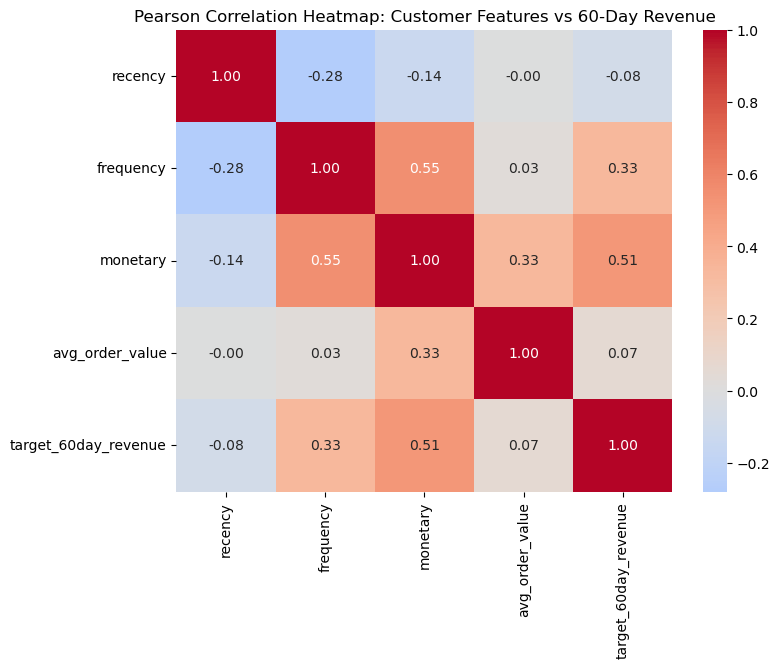

In [25]:
### - Visualize Correlations as Heatmap.

plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Pearson Correlation Heatmap: Customer Features vs 60-Day Revenue")
plt.show()

From the heatmap one can see that 'frequency' and 'monetary' have the largest positive correlations, with 'Monetary' being the strongest linear relationship.  'AOV' is a positive correlation but much weaker.  'Recency' has a negative linear correlation.  From the features themselves, 'AOV' appears positively correlatated 'Monetary'.  Also 'frequency' is positively correlated with 'monetary'. 

Thus, we can conclude customers who buy more will likely buy again soon (frequency).  Customers who historically spend more tend to generate more near-term revenue.  High AOV won't guarantee near-term revenue.  Lastly, very recent customers behave differently, but after a certain point recency will stop being predictive.

***VI. Exploratory Feature Importance - Random Forest***

If I allow a non-linear model to look at this data, does it agree with my findings so far?  I see if RF agrees with my EDA.

In [26]:
### - Random Forest import libaries

from sklearn.ensemble import RandomForestRegressor
import numpy as np
import pandas as pd

In [27]:
### - Feature and Target Selection.  Target will be log transformed.

X = df[['recency','frequency','monetary','avg_order_value']]

y = np.log1p(df['target_60day_revenue'])

In [28]:
### - Fitting lightweight Random Forest

rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,300
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [29]:
### - Extract Feature Importances

importances = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

importances

monetary           0.317684
recency            0.260918
avg_order_value    0.239021
frequency          0.182377
dtype: float64

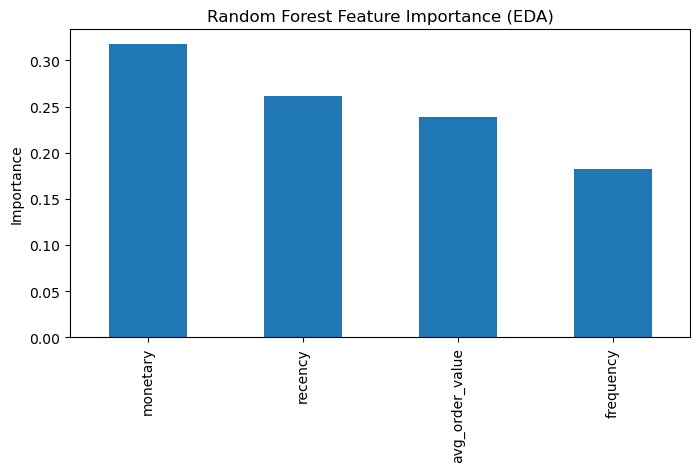

In [30]:
### - Visualize Feature Importance

importances.plot(kind='bar', figsize=(8,4))
plt.title('Random Forest Feature Importance (EDA)')
plt.ylabel('Importance')
plt.show()

From the graph, one can see 'monetary' and 'recency' being the top non-linear drivers.  Recency's ascendence in importance is due to it's non-linear nature.  We can conclude that veing very recent matters, but being old vs very old matters less.  Like Recency, AOV looked different in correlation than it does in Random Forest. We can see now that AOV has a predictive relationship to near-term value. Thus, these two features should be retained in modeling.

***VII. Outliers and Data Quality Review***

From this EDA, one can observe that customer-level variables exhibited extreme values and heavy right-skewed distributions.  Monetary value and AOV contain a small number of extremely high-spend customers.  Frequency shows a right-skew with a small number of active customers.  Recency is not as right-skewed as the other variables.  One key take away from our target is that its zero-inflated.  In other words, 52% of customers generated no revenue in the window.

Each of the features respective extreme values was reviewed for validity.  During data wrangling, all transactions with non-positive unit prices were removed.  This ensured that all revenue (price x number of units sold) calculations are meaningful.  Also from cleaning, no negative quantities or canceled inoices remained in the data set.  High monetary and AOV values correspond to legitimate transactions.  These are valuable customers rather than data errors.  Zero values in the target variable reflect customers who did not purchase during the post-cutoff window.  Not data errors.

The extreme values reflect real, actionable business behavior.  However, in order to handle extreme values, Log Transformations(log1p) were applied for visualization purposes.  Additionally, no further data was removed or capped.  As seen in feature importance, Random Forest proved to be robust to these outliers.

Overall, the dataset is clean, complete, and trustworthy.  Outliers represent valid cusotmer behavior and will be retained to preserve promotional prioritization for signal modeling.

***VIII. EDA Summary***

Exploratory Data Analysis provided a clear understanding of the drivers of near-term customer revenue and guided feature preparation for regression modeling.

From the EDA, one can see our target (60-day revenue) is heavily right-skewed and zero-inflated, with 52% of customers generating no revenue in the post-cutoff window.

With regard to our feature variables, the EDA reveals that when it comes to **Monetary** value,historically high-spend customers generate the most near-term revenue. For **Frequency**, customers with more historical transactions tend to purchase again, though its effect is moderate.  However, exploring **Recency** revealed recent purchases correlate with higher likelihood of near-term revenue in a non-linear fashion. Lastly, EDA revealed that **AOV**, Though weak as a stand alone predictor, if used in combination with monetary value and frequency can provide additional signal.

Thus, 'recency', 'frequency', 'monetary', and 'avg_order_value' will be retained as features in modeling.  These features capture behavioral patterns essential for promotional targeting.

However one must keep in mind that the Pearson correlation underestimated the effect of recency and AOV due to non-linear and segment level behavior.  Also, Zero-inflation in the target variable could affect model performace.  As well as, heavy right-skew and outliers in spending variables may influence linear models.

Thus, prior to modeling, I will log transform 'monetary', 'frequency','avg_order_value', as well as the target variable in order to mitigate skew and reduce dominance of extreme outliers in modeling.  Recency will be retained in raw form.


Thus, the EDA confirms regression is an appropriate framework for predicitng 60-day revenue with log transformation mitigating skew.